In [7]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib
import json

# ============================================================
# 1. LOAD MODEL + SCALERS + FEATURE LIST
# ============================================================

model = load_model("gru_model_20260310_194421.keras")
feature_scaler = joblib.load("feature_scaler.pkl")
target_scaler = joblib.load("target_scaler.pkl")

with open("feature_columns.json") as f:
    feature_cols = json.load(f)

# ============================================================
# 2. LOAD MASTER DATASET
# ============================================================

df = pd.read_parquet("master_monthly.parquet")
df = df.sort_values("month").set_index("month")

# Keep only rows with india_price
df = df.dropna(subset=["india_price"])

# CRITICAL FIX: fill missing external features so last rows survive feature engineering
df = df.ffill().bfill()

print("\n=== LAST 5 ROWS OF PARQUET (AFTER FILL) ===")
print(df.tail(5))

# ============================================================
# 3. FEATURE ENGINEERING (MATCH TRAINING EXACTLY)
# ============================================================

LAGS = [2, 4, 5, 9, 18, 24]

def build_features(raw_df):
    df_feat = raw_df.copy()

    # Lags
    for l in LAGS:
        df_feat[f"lag_{l}"] = df_feat["india_price"].shift(l)

    # Rolling means
    df_feat["roll3"] = df_feat["india_price"].rolling(3).mean()
    df_feat["roll6"] = df_feat["india_price"].rolling(6).mean()
    df_feat["roll12"] = df_feat["india_price"].rolling(12).mean()

    # Volatility
    df_feat["vol3"] = df_feat["india_price"].pct_change().rolling(3).std()
    df_feat["vol6"] = df_feat["india_price"].pct_change().rolling(6).std()

    # Momentum
    df_feat["mom1"] = df_feat["india_price"].diff(1)
    df_feat["mom3"] = df_feat["india_price"].diff(3)
    df_feat["mom6"] = df_feat["india_price"].diff(6)

    # Rolling min/max
    df_feat["roll_min_6"] = df_feat["india_price"].rolling(6).min()
    df_feat["roll_max_6"] = df_feat["india_price"].rolling(6).max()

    # Seasonality
    df_feat["month_num"] = df_feat.index.month
    df_feat = pd.get_dummies(df_feat, columns=["month_num"], drop_first=True)

    # Target (not used for prediction)
    df_feat["return"] = df_feat["india_price"].pct_change()

    # Drop rows with NaNs from lag/rolling windows ONLY
    df_feat = df_feat.dropna()

    # Ensure all feature columns exist
    for col in feature_cols:
        if col not in df_feat.columns:
            df_feat[col] = 0.0

    df_feat = df_feat[feature_cols]
    return df_feat

# ============================================================
# 4. BUILD INITIAL FEATURES + WINDOW
# ============================================================

features_df = build_features(df)

print("\n=== LAST 5 ROWS OF FEATURES_DF ===")
print(features_df.tail(5))
print("\nFEATURE_DF LAST INDEX:", features_df.index[-1])

scaled_features = feature_scaler.transform(features_df)

window = 24
last_window = scaled_features[-window:].reshape(1, window, len(feature_cols))

# Correct last price aligned with features_df
last_price = df.loc[features_df.index[-1], "india_price"]
print("\nActual Last Month Price:", last_price)

# ============================================================
# 5. PREDICT NEXT MONTH (1‑STEP)
# ============================================================

scaled_pred = model.predict(last_window)
pred_return = target_scaler.inverse_transform(scaled_pred)[0][0]
next_price = last_price * (1 + pred_return)

print("Next Month Predicted Price:", next_price)

# ============================================================
# 6. MULTI‑STEP FORECAST (12 MONTHS)
# ============================================================

future_prices = []
current_price = last_price
sim_df = df.copy()
current_window = last_window.copy()

for step in range(12):

    # Predict return
    scaled_pred = model.predict(current_window)
    pred_return = target_scaler.inverse_transform(scaled_pred)[0][0]

    # Compute next price
    current_price = current_price * (1 + pred_return)
    future_prices.append(current_price)

    # Add predicted price to dataframe
    next_month = sim_df.index[-1] + pd.DateOffset(months=1)
    sim_df.loc[next_month, "india_price"] = current_price

    # Rebuild features for updated dataframe
    sim_features_df = build_features(sim_df)

    # Extract last feature row
    new_feat_row = sim_features_df.iloc[-1].values.reshape(1, -1)
    scaled_new_feat_row = feature_scaler.transform(new_feat_row)

    # Update GRU window
    current_window = np.roll(current_window, -1, axis=1)
    current_window[0, -1, :] = scaled_new_feat_row

print("\nNext 12 Months Predicted Prices:")
for i, p in enumerate(future_prices, 1):
    print(f"Month {i}: {p:.2f}")


=== LAST 5 ROWS OF PARQUET (AFTER FILL) ===
            india_price  global_wheat_price  fao_cereals  oil_price  \
month                                                                 
2025-06-01      2506.49            20611.57        107.3  68.169000   
2025-07-01      2528.40            20611.57        106.5  68.390909   
2025-08-01      2587.93            20611.57        105.7  64.864286   
2025-09-01      2577.54            20611.57        104.9  63.959048   
2025-10-01      2540.83            20611.57        103.6  60.894545   

              usd_inr  conflict_events  rainfall  fertiliser_index  \
month                                                                
2025-06-01  85.876500            237.0  1.144187           265.090   
2025-07-01  86.171364            272.0  1.144187           267.034   
2025-08-01  87.569524            227.0  1.144187           271.852   
2025-09-01  88.321429            224.0  1.144187           274.853   
2025-10-01  88.369091            207.

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Next 12 Months Predicted Prices:
Month 1: 2552.26
Month 2: 2588.94
Month 3: 2633.47
Month 4: 2675.91
Month 5: 2712.00
Month 6: 2740.69
Month 7: 2762.56
Month 8: 2778.75
Month 9: 2790.48
Month 10: 2798.83
Month 11: 2804.70
Month 12: 2808.78


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [8]:
def simulate_scenario(model, last_window, feature_cols, feature_scaler, target_scaler,
                      df, feature_name=None, change_type=None, value=None, months=12):

    scenario_window = last_window.copy()

    # Only modify if a scenario is provided
    if feature_name is not None:
        idx = feature_cols.index(feature_name)

        if change_type == "multiply":
            scenario_window[0, -1, idx] *= value
        elif change_type == "add":
            scenario_window[0, -1, idx] += value
        elif change_type == "set":
            scenario_window[0, -1, idx] = value

    current_price = df["india_price"].iloc[-1]
    future_prices = []
    current_window = scenario_window.copy()

    for step in range(months):
        scaled_pred = model.predict(current_window)
        pred_return = target_scaler.inverse_transform(scaled_pred)[0][0]

        current_price = current_price * (1 + pred_return)
        future_prices.append(current_price)

        # Update window
        current_window = np.roll(current_window, -1, axis=1)
        current_window[0, -1, :] = scenario_window[0, -1, :]

    return future_prices

In [9]:
current_price = df["india_price"].iloc[-1]
print("Current Wheat Price:", current_price)

Current Wheat Price: 2540.83


In [10]:
baseline_prices = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name=None, change_type=None, value=None
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [11]:
oil_shock = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="oil_price", change_type="multiply", value=2.40
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [12]:
heatwave = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="temperature", change_type="add", value=3
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [13]:
rainfall_deficit = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="rainfall", change_type="multiply", value=0.70
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [14]:
conflict_spike = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="conflict_events", change_type="set", value=100
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [15]:
fertiliser_shock = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="fertiliser_index", change_type="multiply", value=1.25
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [16]:
currency_depreciation = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="usd_inr", change_type="multiply", value=1.10
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [17]:
global_crash = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="fao_cereals", change_type="multiply", value=0.80
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [18]:
uncertainty_rise = simulate_scenario(
    model, last_window, feature_cols, feature_scaler, target_scaler, df,
    feature_name="gepu", change_type="multiply", value=1.50
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [19]:
scenarios = {
    "Baseline": baseline_prices,
    "Oil Shock (+40%)": oil_shock,
    "Heatwave (+3°C)": heatwave,
    "Rainfall Deficit (-30%)": rainfall_deficit,
    "Conflict Spike (100 events)": conflict_spike,
    "Fertiliser Shock (+25%)": fertiliser_shock,
    "Currency Depreciation (+10%)": currency_depreciation,
    "Global Wheat Crash (-20%)": global_crash,
    "Uncertainty Rise (+50%)": uncertainty_rise
}
print(f"Current Wheat Price: {current_price:.2f}\n")

for name, prices in scenarios.items():
    print(f"{name}:")
    print(f"  Month 1: {prices[0]:.2f}")
    print(f"  Month 6: {prices[5]:.2f}")
    print(f"  Month 12: {prices[-1]:.2f}\n")

Current Wheat Price: 2540.83

Baseline:
  Month 1: 2552.26
  Month 6: 2740.69
  Month 12: 2808.78

Oil Shock (+40%):
  Month 1: 2552.98
  Month 6: 2771.22
  Month 12: 2897.65

Heatwave (+3°C):
  Month 1: 2566.91
  Month 6: 3115.36
  Month 12: 4115.61

Rainfall Deficit (-30%):
  Month 1: 2552.03
  Month 6: 2736.02
  Month 12: 2797.34

Conflict Spike (100 events):
  Month 1: 2546.37
  Month 6: 3022.51
  Month 12: 4137.92

Fertiliser Shock (+25%):
  Month 1: 2553.36
  Month 6: 2765.16
  Month 12: 2886.30

Currency Depreciation (+10%):
  Month 1: 2551.50
  Month 6: 2731.37
  Month 12: 2784.69

Global Wheat Crash (-20%):
  Month 1: 2552.89
  Month 6: 2752.83
  Month 12: 2837.62

Uncertainty Rise (+50%):
  Month 1: 2555.06
  Month 6: 2779.66
  Month 12: 2897.67



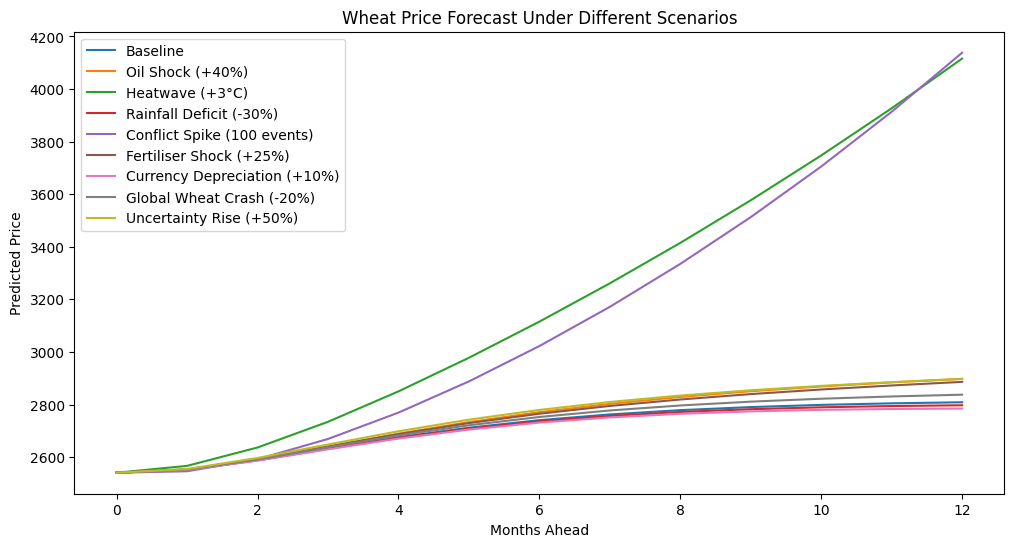

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for name, prices in scenarios.items():
    plt.plot([current_price] + prices, label=name)

plt.legend()
plt.title("Wheat Price Forecast Under Different Scenarios")
plt.xlabel("Months Ahead")
plt.ylabel("Predicted Price")

# Save before showing
plt.savefig("scenario_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

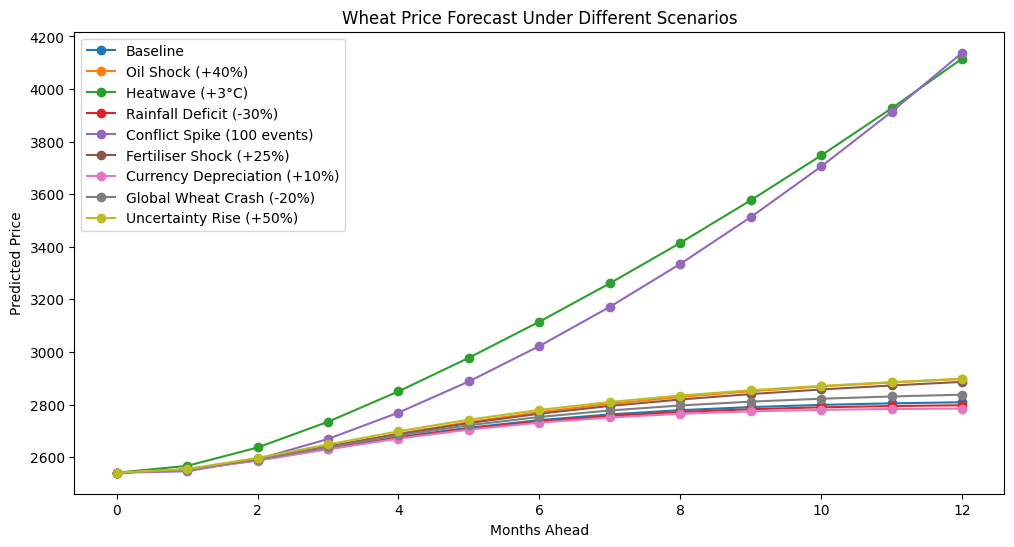

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for name, prices in scenarios.items():
    full_series = [current_price] + prices
    plt.plot(full_series, marker="o", label=name)   # <-- markers added

plt.legend()
plt.title("Wheat Price Forecast Under Different Scenarios")
plt.xlabel("Months Ahead")
plt.ylabel("Predicted Price")

plt.savefig("scenario_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Lags
for l in [2, 4, 5, 9, 18, 24]:
    df[f"lag_{l}"] = df["india_price"].shift(l)

# Rolling means
df["roll3"] = df["india_price"].rolling(3).mean()
df["roll6"] = df["india_price"].rolling(6).mean()
df["roll12"] = df["india_price"].rolling(12).mean()

# Volatility
df["vol3"] = df["india_price"].pct_change().rolling(3).std()
df["vol6"] = df["india_price"].pct_change().rolling(6).std()

# Momentum
df["mom1"] = df["india_price"].diff(1)
df["mom3"] = df["india_price"].diff(3)
df["mom6"] = df["india_price"].diff(6)

# Rolling min/max
df["roll_min_6"] = df["india_price"].rolling(6).min()
df["roll_max_6"] = df["india_price"].rolling(6).max()

# Seasonality
df["month_num"] = df.index.month
df = pd.get_dummies(df, columns=["month_num"], drop_first=True)

# Target
df["return"] = df["india_price"].pct_change()
df = df.dropna()

scaled_features = feature_scaler.transform(df[feature_cols])

window = 24
X = []
y = []

for i in range(window, len(scaled_features)):
    X.append(scaled_features[i-window:i])
    y.append(df["return"].iloc[i])

X = np.array(X)
y = np.array(y).reshape(-1, 1)

split = int(len(X) * 0.7)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [22]:
import numpy as np
import pandas as pd

def permutation_importance(model, X_test, y_test, feature_cols, target_scaler, n_repeats=5):
    baseline_pred = model.predict(X_test)
    baseline_pred = target_scaler.inverse_transform(baseline_pred)
    baseline_error = np.mean(np.abs(baseline_pred - y_test))

    importances = {}

    for i, col in enumerate(feature_cols):
        errors = []

        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            np.random.shuffle(X_permuted[:, :, i])  # shuffle feature i across time

            perm_pred = model.predict(X_permuted)
            perm_pred = target_scaler.inverse_transform(perm_pred)

            error = np.mean(np.abs(perm_pred - y_test))
            errors.append(error)

        importances[col] = np.mean(errors) - baseline_error

    return importances

In [23]:
importances = permutation_importance(
    model,
    X_test,          # your test windows
    y_test,          # your true returns
    feature_cols,
    target_scaler
)

sorted_importance = sorted(importances.items(), key=lambda x: x[1], reverse=True)

for feature, score in sorted_importance:
    print(f"{feature}: {score:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━

In [24]:
import shap
import numpy as np

# -----------------------------
# 1. Flatten X_test for SHAP
# -----------------------------
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# -----------------------------
# 2. Prediction function for SHAP
# -----------------------------
def predict_fn(x):
    x_reshaped = x.reshape(x.shape[0], 24, len(feature_cols))
    return model.predict(x_reshaped)

# -----------------------------
# 3. Background sample (must match shape)
# -----------------------------
background = X_test_flat[:50]   # SAME SHAPE as X_test_flat

# -----------------------------
# 4. Create KernelExplainer
# -----------------------------
explainer = shap.KernelExplainer(predict_fn, background)

# -----------------------------
# 5. Compute SHAP values
# -----------------------------
shap_values = explainer.shap_values(X_test_flat[:20])

# -----------------------------
# 6. Create feature names
# -----------------------------
flat_feature_names = [
    f"{col}_t{t}" for t in range(24) for col in feature_cols
]

# -----------------------------
# 7. SHAP summary plot
# -----------------------------
shap.summary_plot(
    shap_values[0],              # <-- IMPORTANT
    X_test_flat[:20],            # <-- SAME SHAPE
    feature_names=flat_feature_names
)

# -----------------------------
# # 8. SHAP bar plot
# # -----------------------------
# shap.summary_plot(
#     shap_values[0],
#     X_test_flat[:20],
#     feature_names=flat_feature_names,
#     plot_type="bar"
# )

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


  0%|                                                                                                                                          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
5900/5900 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step


  5%|██████▌                                                                                                                           | 1/20 [00:38<12:17, 38.84s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
5900/5900 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step


 95%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌      | 19/20 [16:00<01:02, 62.17s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
5900/5900 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [16:41<00:00, 50.09s/it]


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
print("SHAP shape:", shap_values[0].shape)
print("Input shape:", X_test_flat[:20].shape)
print("Background shape:", background.shape)
print("Feature count:", len(feature_cols))

In [ ]:
import tensorflow as tf
import numpy as np

# -----------------------------
# 1. Integrated Gradients function
# -----------------------------
def integrated_gradients(model, 
                         baseline, 
                         input_sample, 
                         steps=50):
    
    # Scale inputs from baseline → input
    interpolated = [
        baseline + (float(i) / steps) * (input_sample - baseline)
        for i in range(steps + 1)
    ]
    interpolated = tf.convert_to_tensor(interpolated, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)

    grads = tape.gradient(preds, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0)

    integrated_grads = (input_sample - baseline) * avg_grads
    return integrated_grads.numpy()

# -----------------------------
# 2. Choose a baseline (zero input)
# -----------------------------
baseline = np.zeros_like(X_test[0])

# -----------------------------
# 3. Compute IG for one sample
# -----------------------------
ig = integrated_gradients(model, baseline, X_test[0])

# ig shape = (24 timesteps, n_features)

In [ ]:
def occlusion_importance(model, X_sample, feature_cols):
    base_pred = model.predict(X_sample[np.newaxis, ...])[0][0]
    n_features = X_sample.shape[1]

    importances = {}

    for i, col in enumerate(feature_cols):
        X_occluded = X_sample.copy()
        X_occluded[:, i] = 0  # zero out feature across all timesteps

        occluded_pred = model.predict(X_occluded[np.newaxis, ...])[0][0]
        importances[col] = abs(base_pred - occluded_pred)

    return importances

# Compute occlusion importance for one sample
occ = occlusion_importance(model, X_test[0], feature_cols)

In [ ]:
import pandas as pd

df_importance = pd.DataFrame({
    "feature": feature_cols,
    "permutation": [importances[f] for f in feature_cols],
    "occlusion": [occ[f] for f in feature_cols],
})

df_importance["combined_score"] = (
    df_importance["permutation"].rank() +
    df_importance["occlusion"].rank()
)

df_importance.sort_values("combined_score", ascending=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. Sort by combined_score and select Top 10 features
# ---------------------------------------------------------
df_top10 = df_importance.sort_values("combined_score", ascending=False).head(10)

# Ensure consistent ordering for plots
df_top10 = df_top10.sort_values("combined_score", ascending=True)

# ---------------------------------------------------------
# 2. Create the dashboard layout
# ---------------------------------------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Feature Importance Dashboard (Top 10 Features)", fontsize=20, y=0.95)

# ---------------------------------------------------------
# Plot 1 — Combined Score (Bar Chart)
# ---------------------------------------------------------
sns.barplot(
    data=df_top10,
    x="combined_score",
    y="feature",
    ax=axes[0, 0],
    palette="viridis"
)
axes[0, 0].set_title("Combined Feature Importance Score")
axes[0, 0].set_xlabel("Combined Score")
axes[0, 0].set_ylabel("Feature")

# ---------------------------------------------------------
# Plot 2 — Permutation vs Occlusion (Scatter Plot)
# ---------------------------------------------------------
sns.scatterplot(
    data=df_top10,
    x="permutation",
    y="occlusion",
    hue="feature",
    s=120,
    ax=axes[0, 1],
    palette="tab10"
)
axes[0, 1].set_title("Permutation vs Occlusion Importance")
axes[0, 1].set_xlabel("Permutation Importance")
axes[0, 1].set_ylabel("Occlusion Importance")
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# Plot 3 — Heatmap of Importance Values
# ---------------------------------------------------------
heatmap_data = df_top10.set_index("feature")[["permutation", "occlusion", "combined_score"]]

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Heatmap of Feature Importance Metrics")

# ---------------------------------------------------------
# Plot 4 — Top 10 Features (Horizontal Bar Chart)
# ---------------------------------------------------------
sns.barplot(
    data=df_top10,
    y="feature",
    x="occlusion",
    ax=axes[1, 1],
    palette="magma"
)
axes[1, 1].set_title("Top 10 Features by Occlusion Sensitivity")
axes[1, 1].set_xlabel("Occlusion Importance")
axes[1, 1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_36980\4294236455.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_36980\4294236455.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


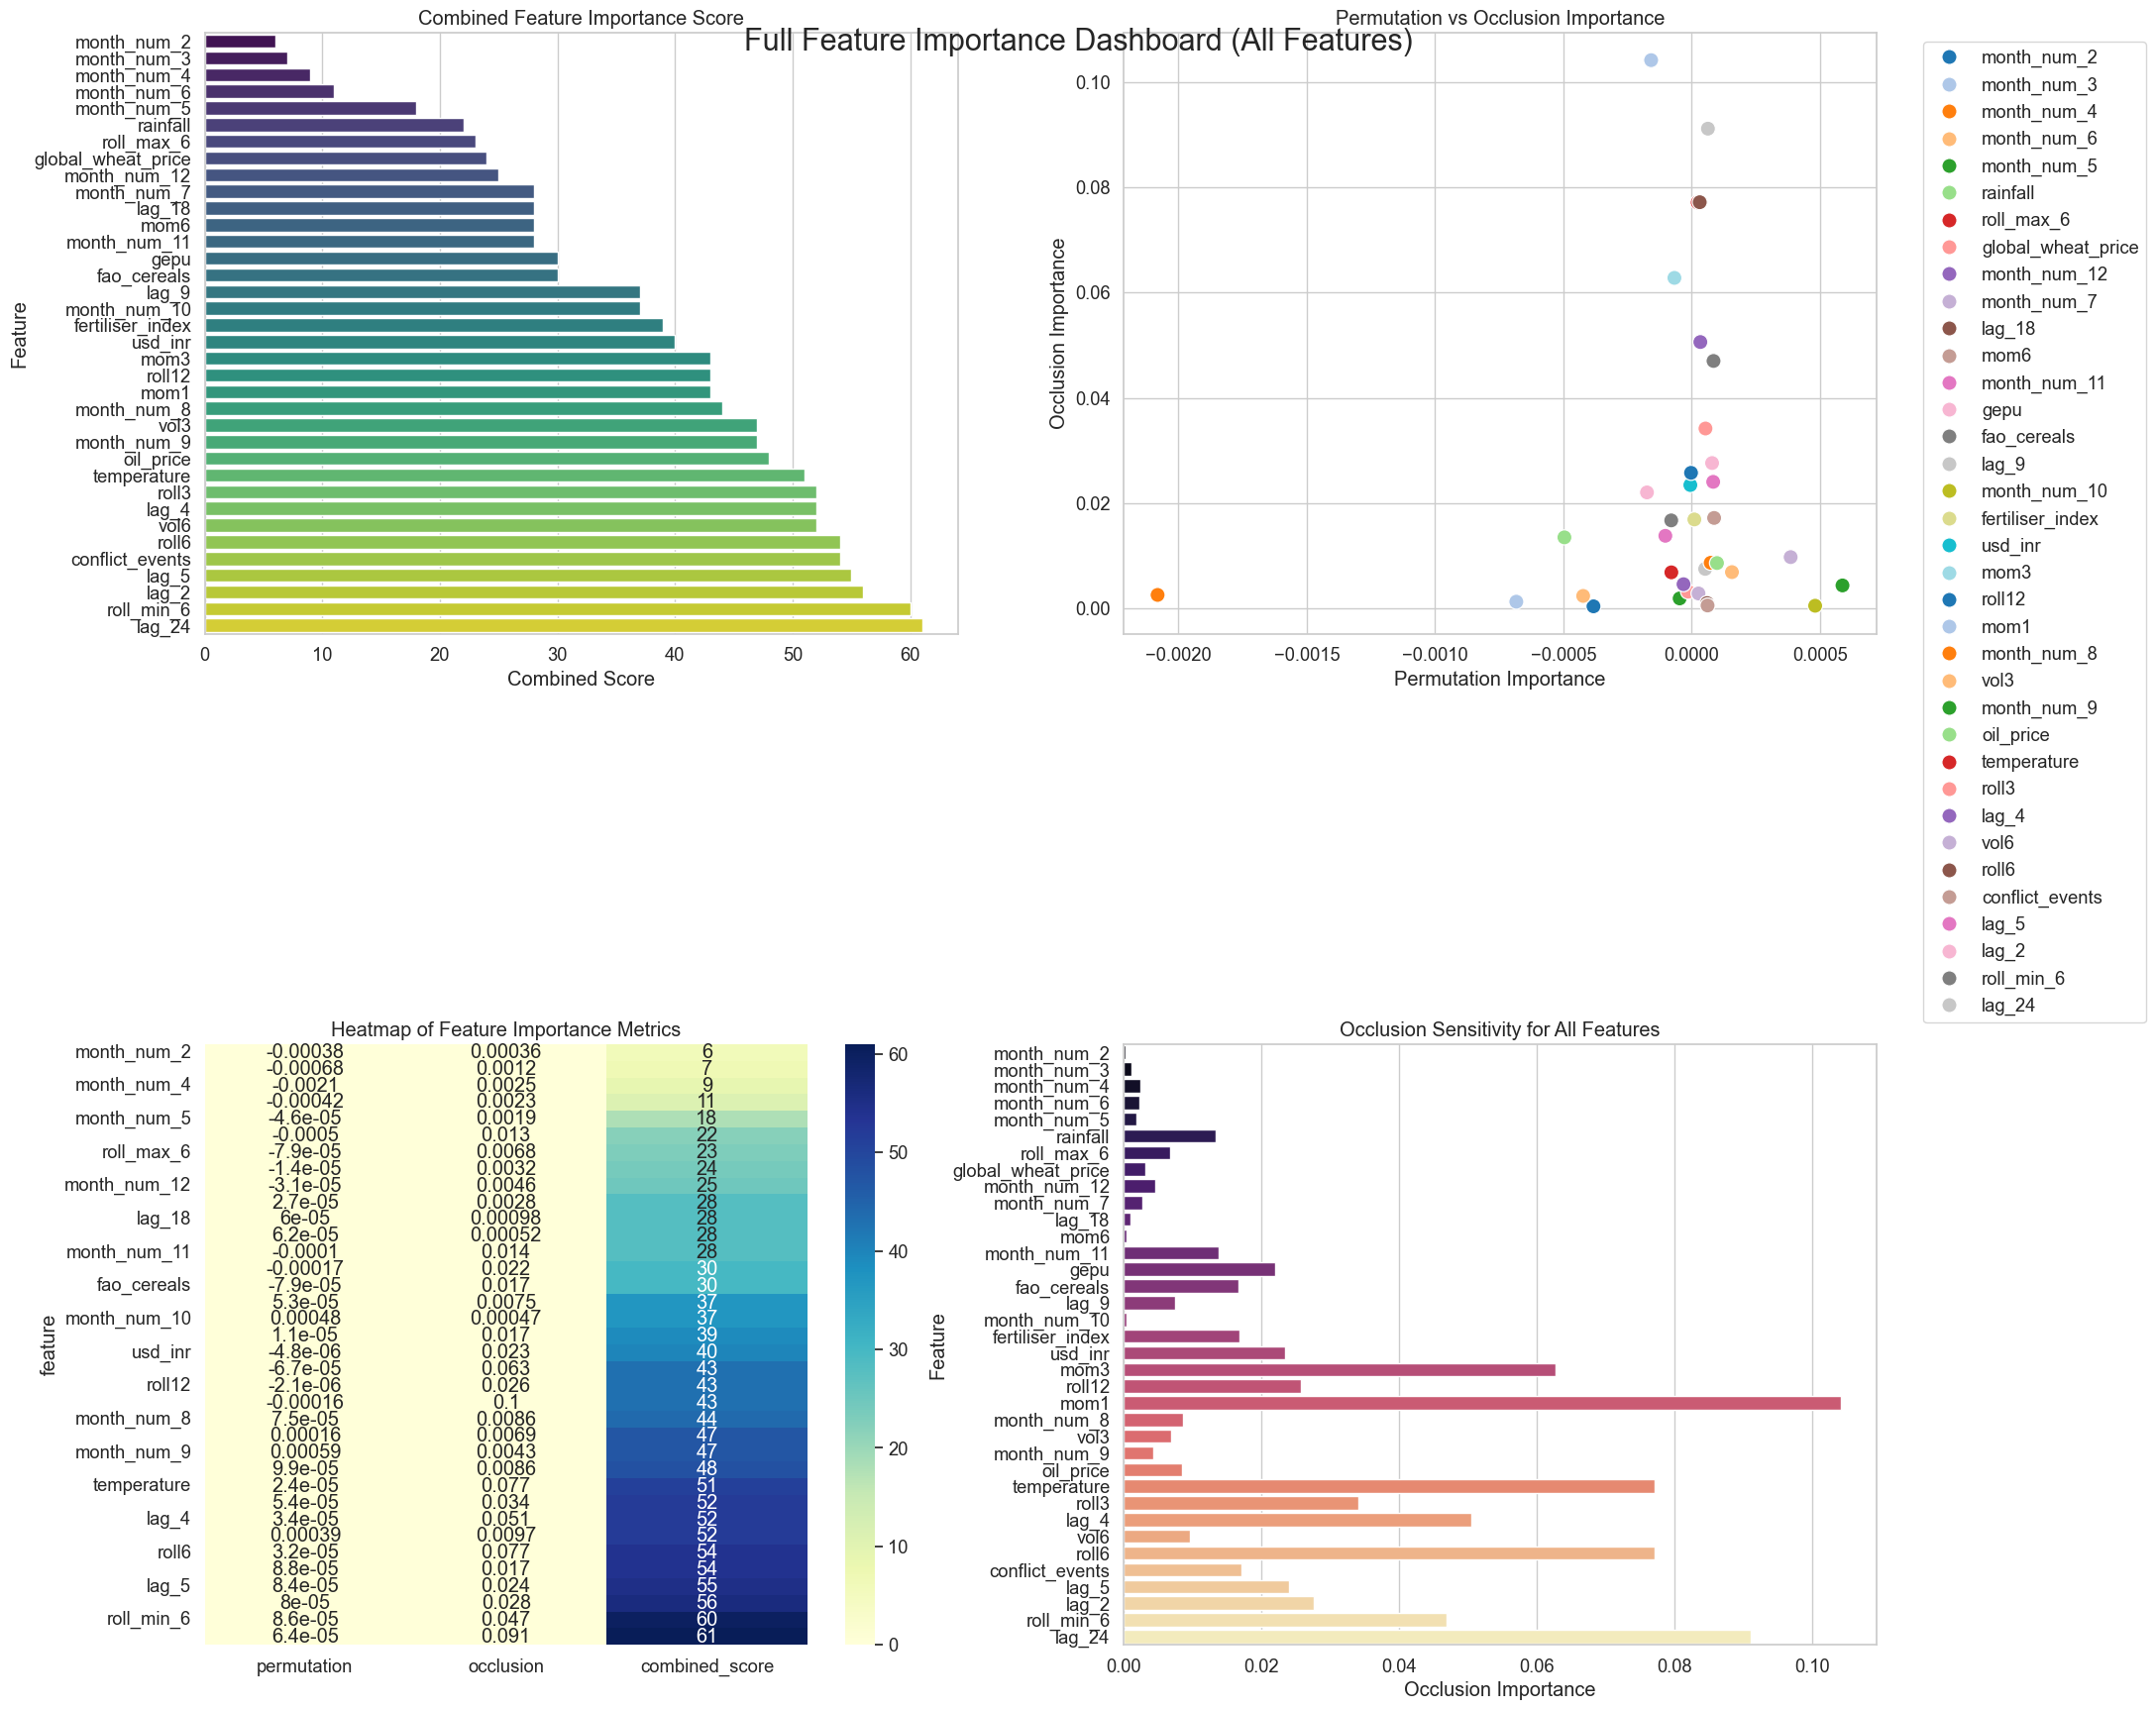

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. Sort ALL features by combined_score
# ---------------------------------------------------------
df_all = df_importance.sort_values("combined_score", ascending=True)

# ---------------------------------------------------------
# 2. Create the dashboard layout
# ---------------------------------------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle("Full Feature Importance Dashboard (All Features)", fontsize=22, y=0.95)

# ---------------------------------------------------------
# Plot 1 — Combined Score (Bar Chart)
# ---------------------------------------------------------
sns.barplot(
    data=df_all,
    x="combined_score",
    y="feature",
    ax=axes[0, 0],
    palette="viridis"
)
axes[0, 0].set_title("Combined Feature Importance Score")
axes[0, 0].set_xlabel("Combined Score")
axes[0, 0].set_ylabel("Feature")

# ---------------------------------------------------------
# Plot 2 — Permutation vs Occlusion (Scatter Plot)
# ---------------------------------------------------------
sns.scatterplot(
    data=df_all,
    x="permutation",
    y="occlusion",
    hue="feature",
    s=120,
    ax=axes[0, 1],
    palette="tab20"
)
axes[0, 1].set_title("Permutation vs Occlusion Importance")
axes[0, 1].set_xlabel("Permutation Importance")
axes[0, 1].set_ylabel("Occlusion Importance")
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# Plot 3 — Heatmap of Importance Values
# ---------------------------------------------------------
heatmap_data = df_all.set_index("feature")[["permutation", "occlusion", "combined_score"]]

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Heatmap of Feature Importance Metrics")

# ---------------------------------------------------------
# Plot 4 — Occlusion Importance (Bar Chart)
# ---------------------------------------------------------
sns.barplot(
    data=df_all,
    y="feature",
    x="occlusion",
    ax=axes[1, 1],
    palette="magma"
)
axes[1, 1].set_title("Occlusion Sensitivity for All Features")
axes[1, 1].set_xlabel("Occlusion Importance")
axes[1, 1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_36980\3970198631.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_36980\3970198631.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


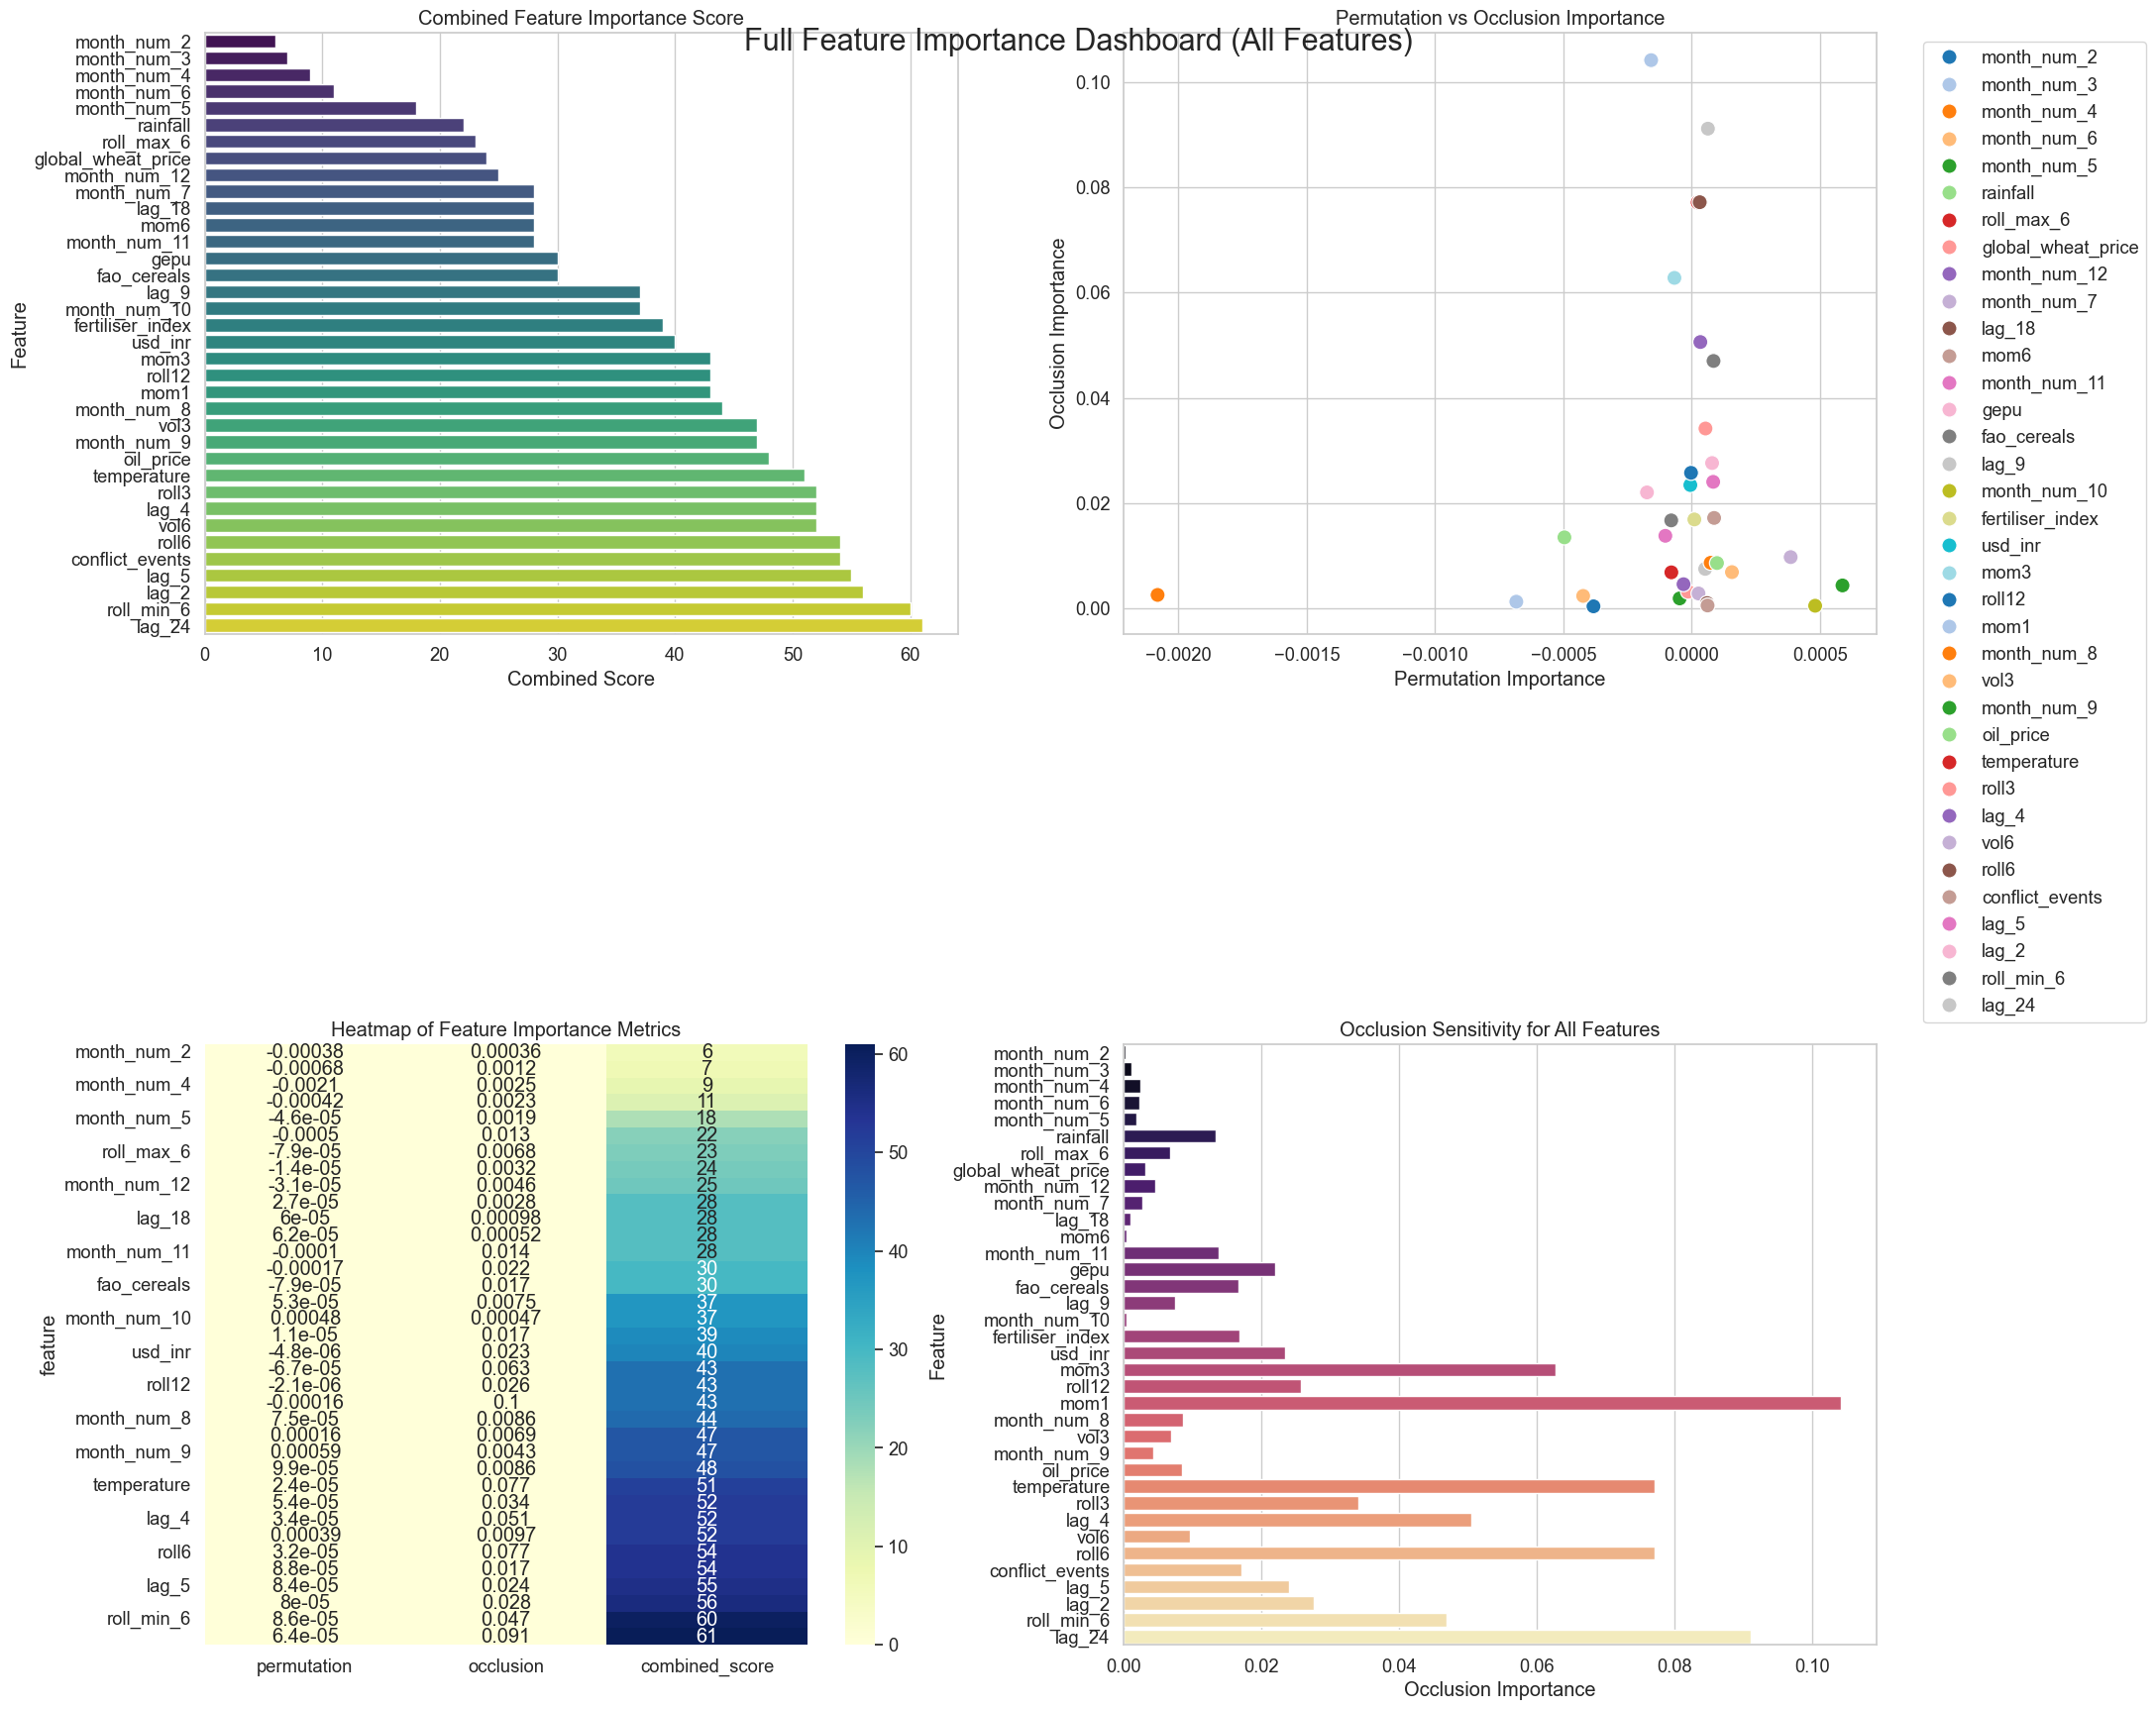

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. Sort ALL features by combined_score
# ---------------------------------------------------------
df_all = df_importance.sort_values("combined_score", ascending=True)

# ---------------------------------------------------------
# 2. Create the dashboard layout
# ---------------------------------------------------------
sns.set(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.suptitle("Full Feature Importance Dashboard (All Features)", fontsize=22, y=0.95)

# ---------------------------------------------------------
# Plot 1 — Combined Score (Bar Chart)
# ---------------------------------------------------------
sns.barplot(
    data=df_all,
    x="combined_score",
    y="feature",
    ax=axes[0, 0],
    palette="viridis"
)
axes[0, 0].set_title("Combined Feature Importance Score")
axes[0, 0].set_xlabel("Combined Score")
axes[0, 0].set_ylabel("Feature")

# ---------------------------------------------------------
# Plot 2 — Permutation vs Occlusion (Scatter Plot)
# ---------------------------------------------------------
sns.scatterplot(
    data=df_all,
    x="permutation",
    y="occlusion",
    hue="feature",
    s=120,
    ax=axes[0, 1],
    palette="tab20"
)
axes[0, 1].set_title("Permutation vs Occlusion Importance")
axes[0, 1].set_xlabel("Permutation Importance")
axes[0, 1].set_ylabel("Occlusion Importance")
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# Plot 3 — Heatmap of Importance Values
# ---------------------------------------------------------
heatmap_data = df_all.set_index("feature")[["permutation", "occlusion", "combined_score"]]

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Heatmap of Feature Importance Metrics")

# ---------------------------------------------------------
# Plot 4 — Occlusion Importance (Bar Chart)
# ---------------------------------------------------------
sns.barplot(
    data=df_all,
    y="feature",
    x="occlusion",
    ax=axes[1, 1],
    palette="magma"
)
axes[1, 1].set_title("Occlusion Sensitivity for All Features")
axes[1, 1].set_xlabel("Occlusion Importance")
axes[1, 1].set_ylabel("Feature")

plt.tight_layout()

# ---------------------------------------------------------
# SAVE THE FIGURE
# ---------------------------------------------------------
plt.savefig("feature_importance_dashboard.png", dpi=300, bbox_inches="tight")

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_36980\799718038.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


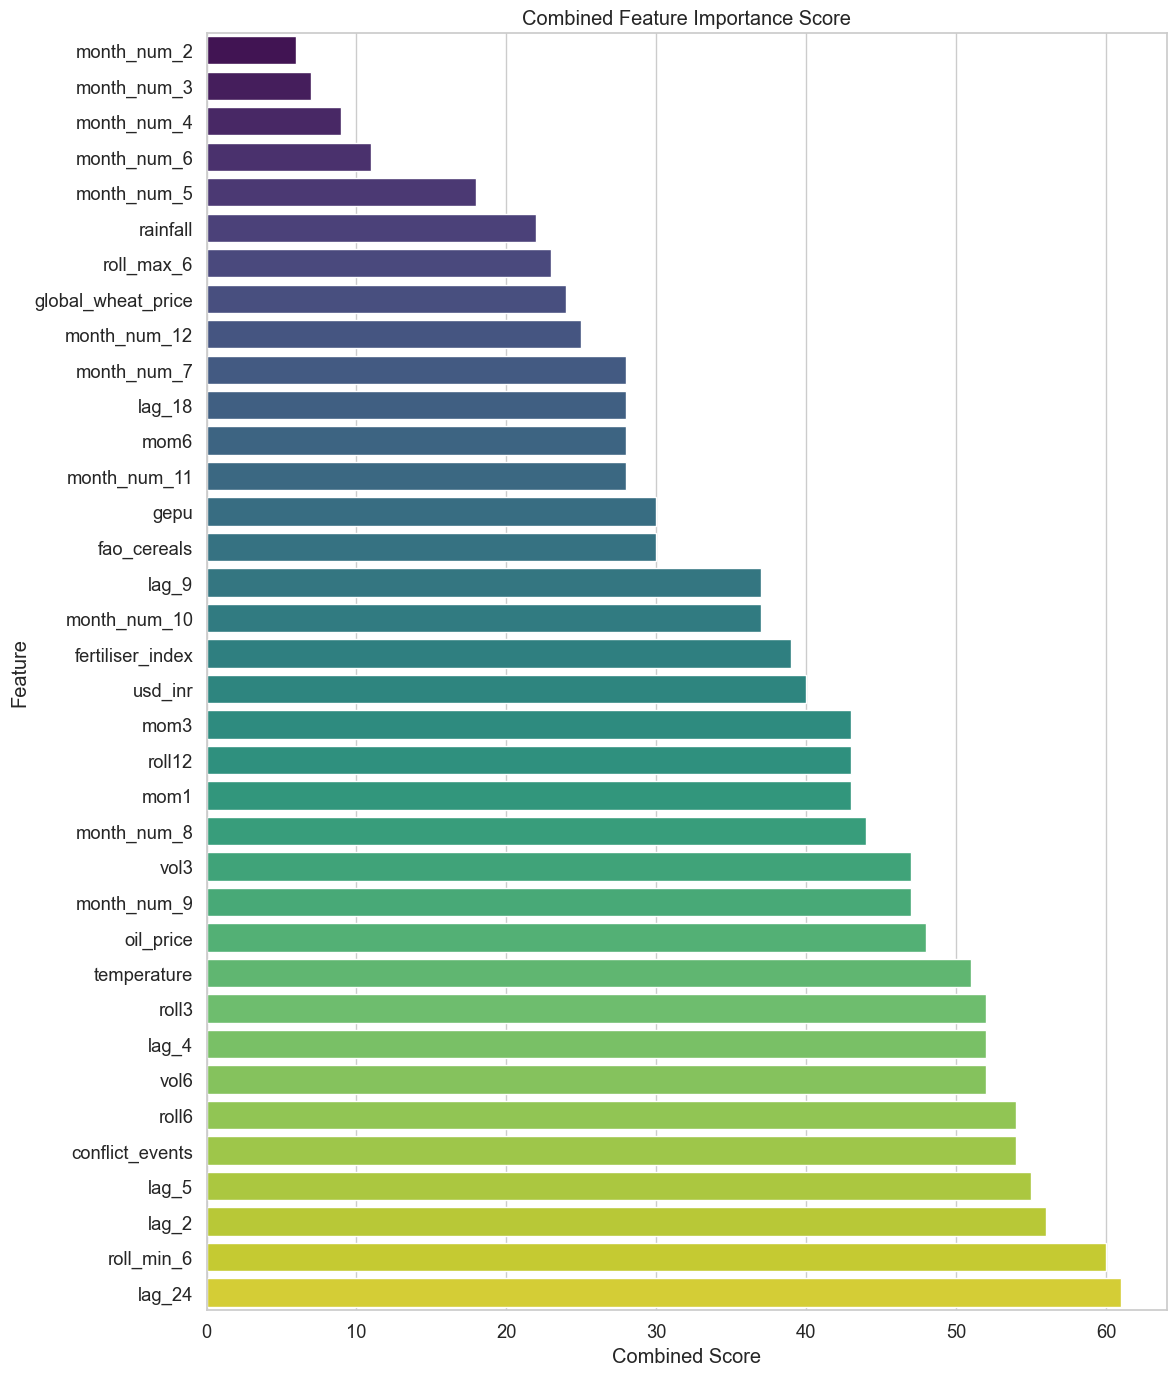

In [68]:
plt.figure(figsize=(12, 14))
sns.barplot(
    data=df_all,
    x="combined_score",
    y="feature",
    palette="viridis"
)
plt.title("Combined Feature Importance Score")
plt.xlabel("Combined Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("combined_score_all_features.png", dpi=300, bbox_inches="tight")
plt.show()

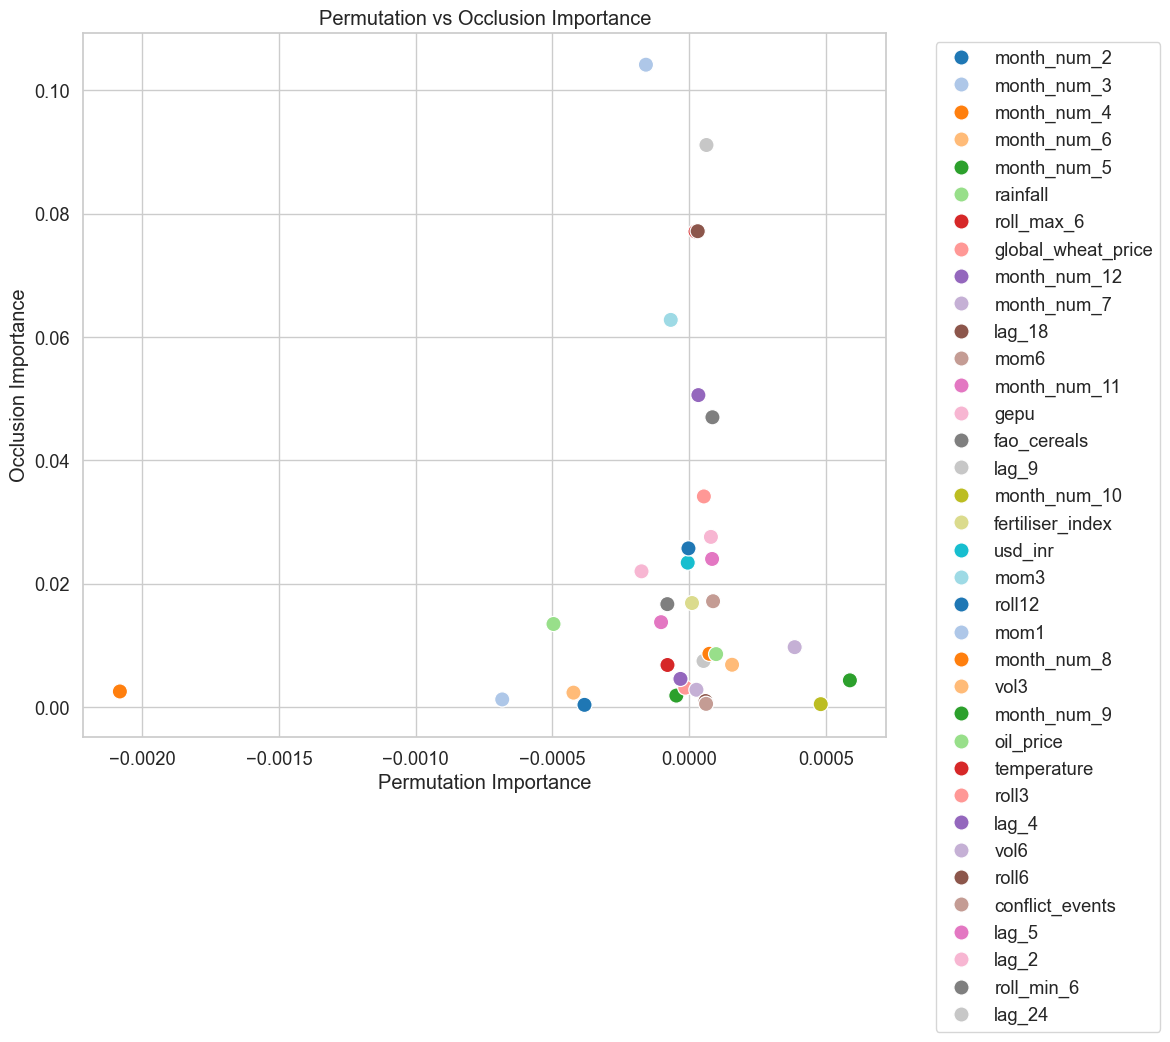

In [69]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_all,
    x="permutation",
    y="occlusion",
    hue="feature",
    s=120,
    palette="tab20"
)
plt.title("Permutation vs Occlusion Importance")
plt.xlabel("Permutation Importance")
plt.ylabel("Occlusion Importance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("permutation_vs_occlusion.png", dpi=300, bbox_inches="tight")
plt.show()

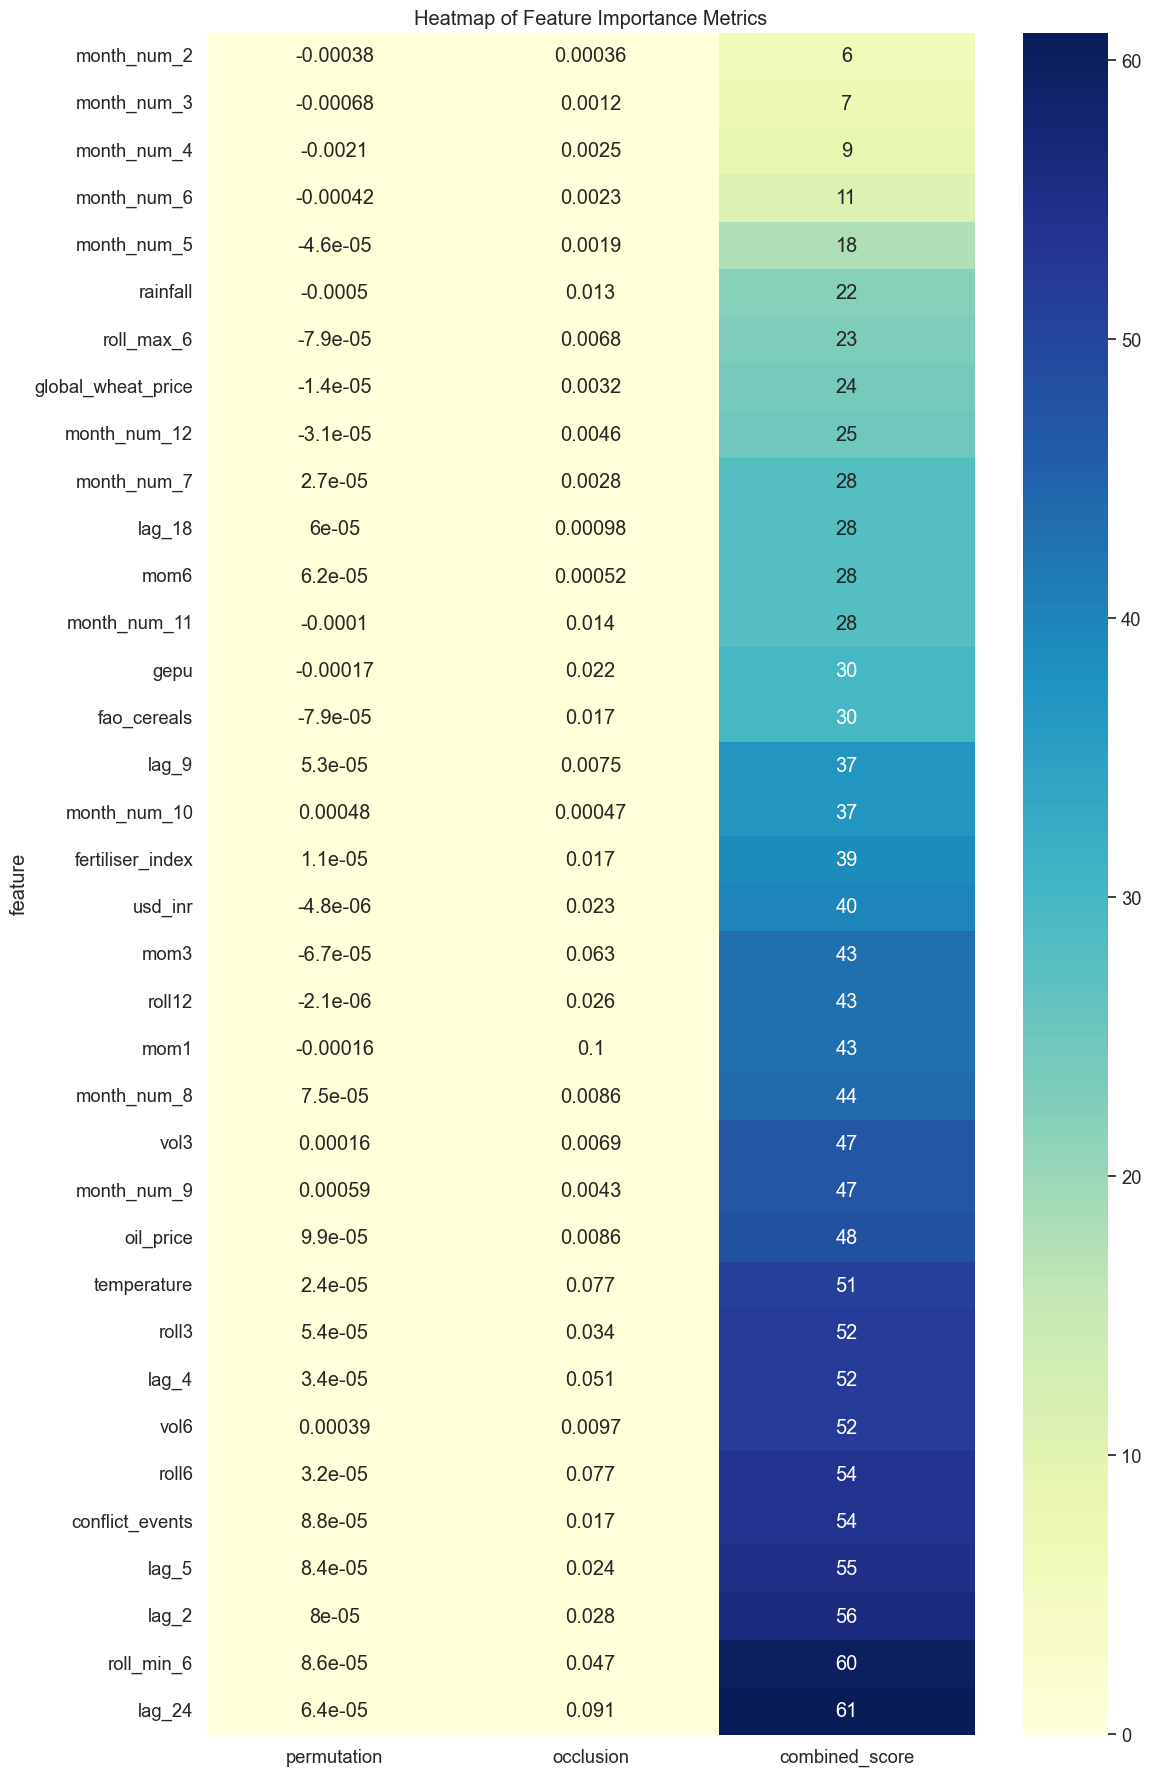

In [70]:
plt.figure(figsize=(12, 18))
heatmap_data = df_all.set_index("feature")[["permutation", "occlusion", "combined_score"]]

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu"
)
plt.title("Heatmap of Feature Importance Metrics")

plt.tight_layout()
plt.savefig("importance_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_36980\2826869295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


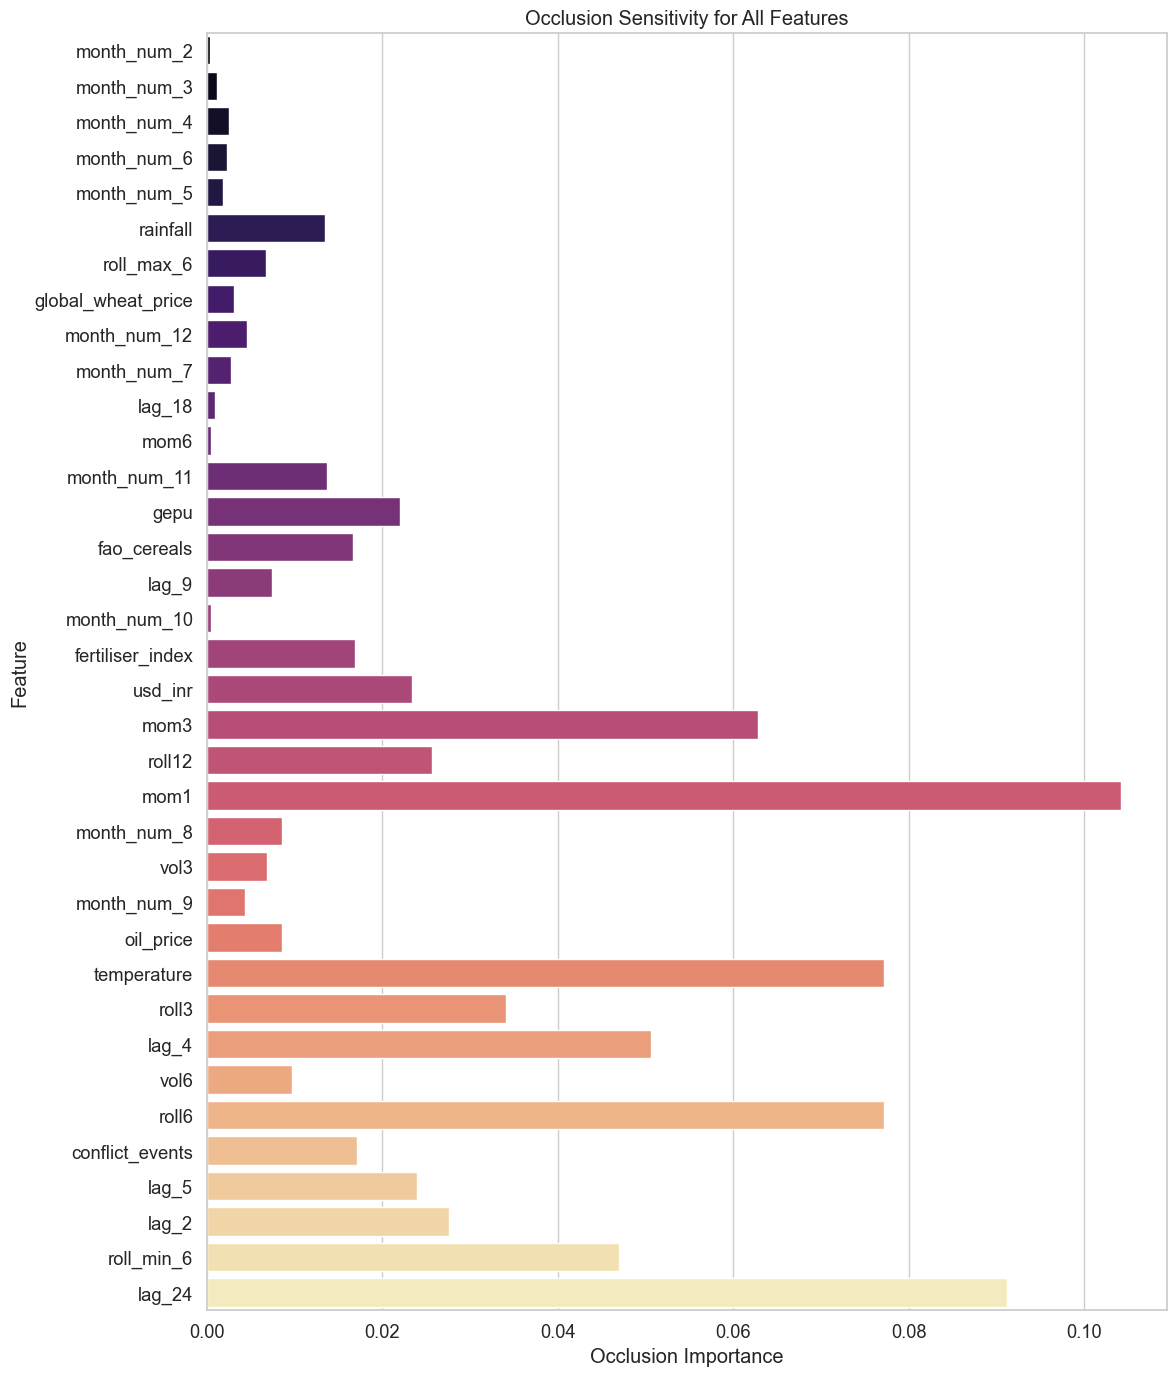

In [71]:
plt.figure(figsize=(12, 14))
sns.barplot(
    data=df_all,
    y="feature",
    x="occlusion",
    palette="magma"
)
plt.title("Occlusion Sensitivity for All Features")
plt.xlabel("Occlusion Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("occlusion_importance_all_features.png", dpi=300, bbox_inches="tight")
plt.show()

In [72]:
df_all["perm_abs"] = df_all["permutation"].abs()

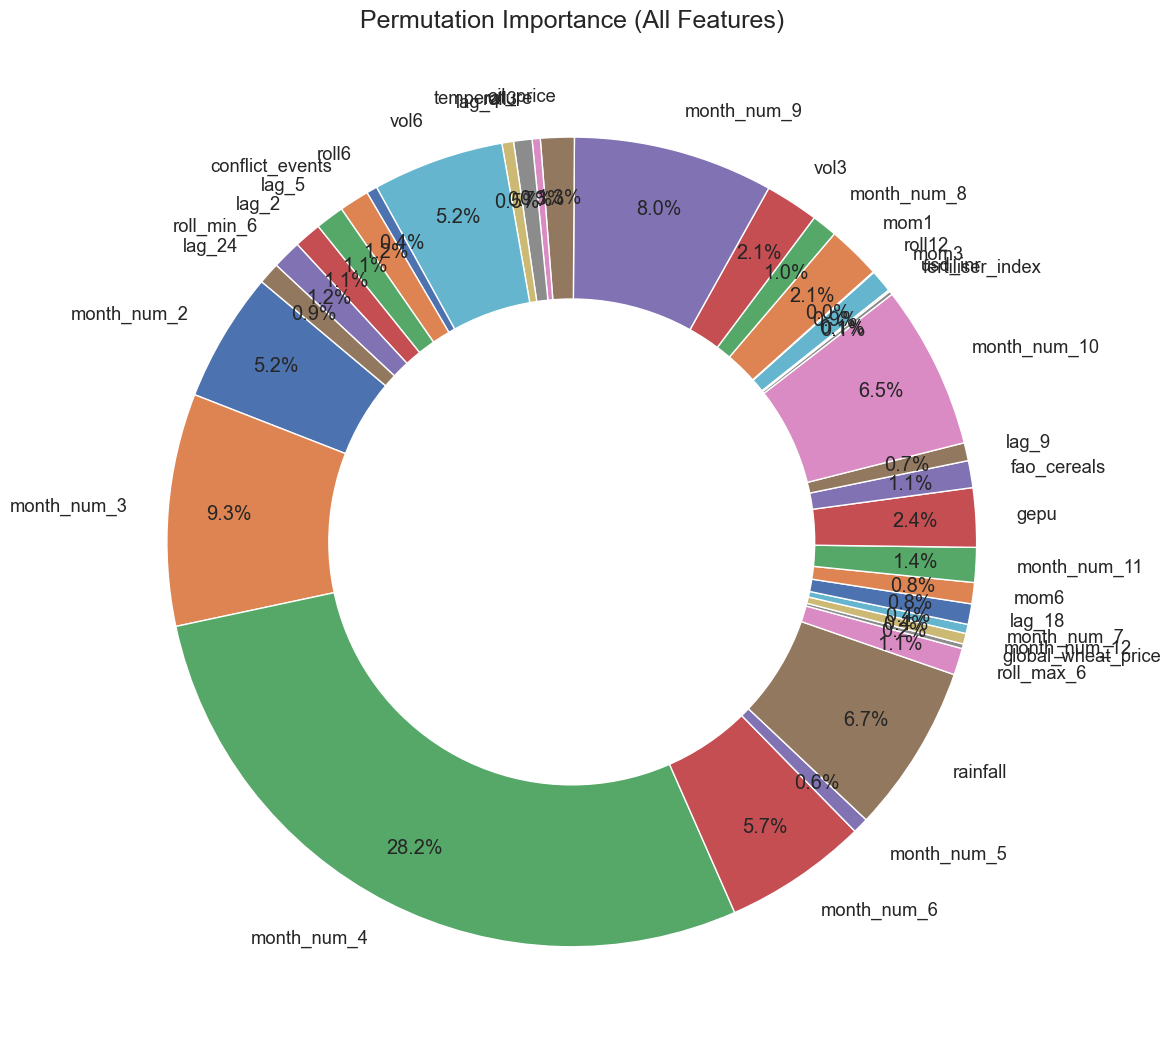

In [73]:
import matplotlib.pyplot as plt

# Use absolute permutation importance
df_all["perm_abs"] = df_all["permutation"].abs()

plt.figure(figsize=(12, 12))

plt.pie(
    df_all["perm_abs"],
    labels=df_all["feature"],
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85
)

# Make it look like a donut chart (cleaner)
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Permutation Importance (All Features)", fontsize=18)
plt.tight_layout()

# Save the figure
plt.savefig("permutation_importance_pie.png", dpi=300, bbox_inches="tight")

plt.show()